In [35]:
import pandas as pd
import numpy as np

In [36]:
df = pd.read_csv('/content/Wine_clust.csv')

In [37]:
df.shape

(178, 13)

In [38]:
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


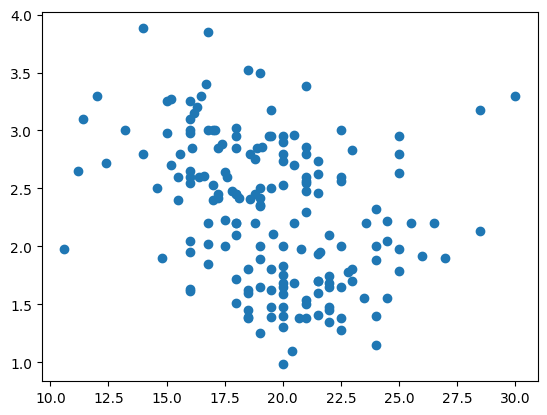

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.scatter(df['Ash_Alcanity'],df['Total_Phenols'])
plt.show()

# Scaling

In [40]:
from sklearn.preprocessing import StandardScaler


In [41]:
ss = StandardScaler()
df_scaled = ss.fit_transform(df)

In [42]:
df_scaled

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]])

# K-Means Algorithm

In [43]:
from sklearn.cluster import KMeans

In [44]:
from sklearn.decomposition import PCA

In [45]:
wcss = []
ks = range(1,15)

for k in ks:
  model = KMeans(n_clusters =k)
  model.fit(df_scaled)
  wcss.append(model.inertia_)


In [46]:
wcss

[2313.9999999999986,
 1659.0079672511504,
 1279.9661527749458,
 1185.5266132872025,
 1116.4431166146999,
 1050.0778258222126,
 1007.152671533571,
 942.6294645649681,
 946.9697050529408,
 875.773216762831,
 898.9504186270152,
 846.1678577558209,
 794.8270705888622,
 759.2146926243772]

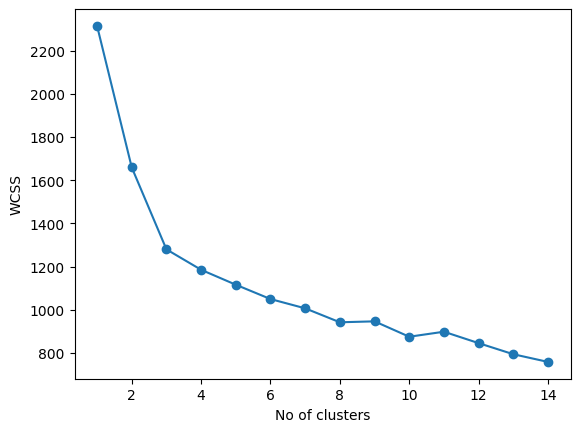

In [47]:
plt.plot(ks,wcss,'-o')
plt.xlabel("No of clusters")
plt.ylabel("WCSS")
plt.show()


In [48]:
model_KMeans = KMeans(n_clusters =3)
model_KMeans.fit(df_scaled)

KMeans(n_clusters=3)

In [49]:
labels = model_KMeans.predict(df_scaled)

In [50]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2], dtype=int32)

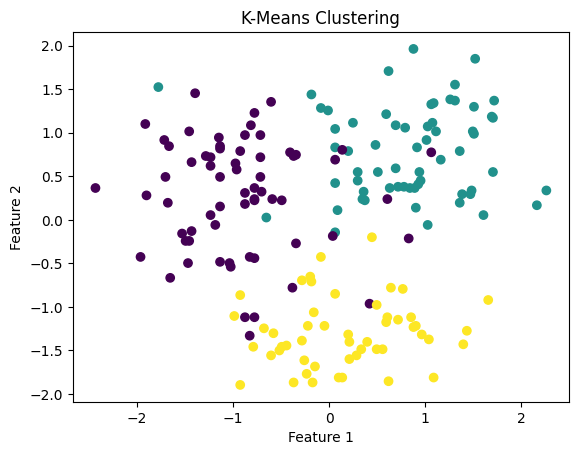

In [51]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

plt.scatter(df_scaled[:,0],df_scaled[:,11],c=labels)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering')
plt.show()

## Using PCA

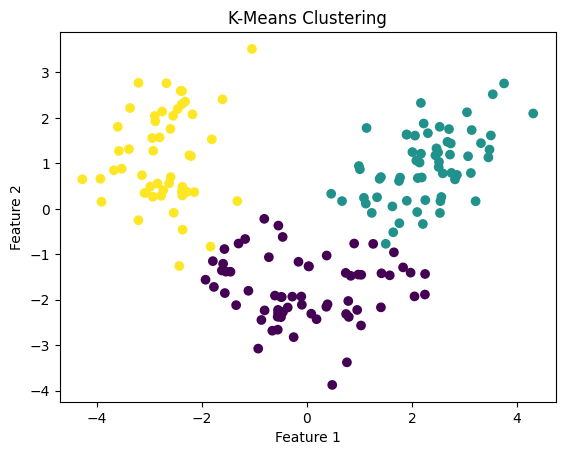

In [52]:
pca = PCA(n_components=3)
df_pca = pca.fit_transform(df_scaled)
plt.figure()
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering')
plt.show()

#Agglomerative Clustering

In [53]:
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [54]:
import scipy.cluster.hierarchy as shc

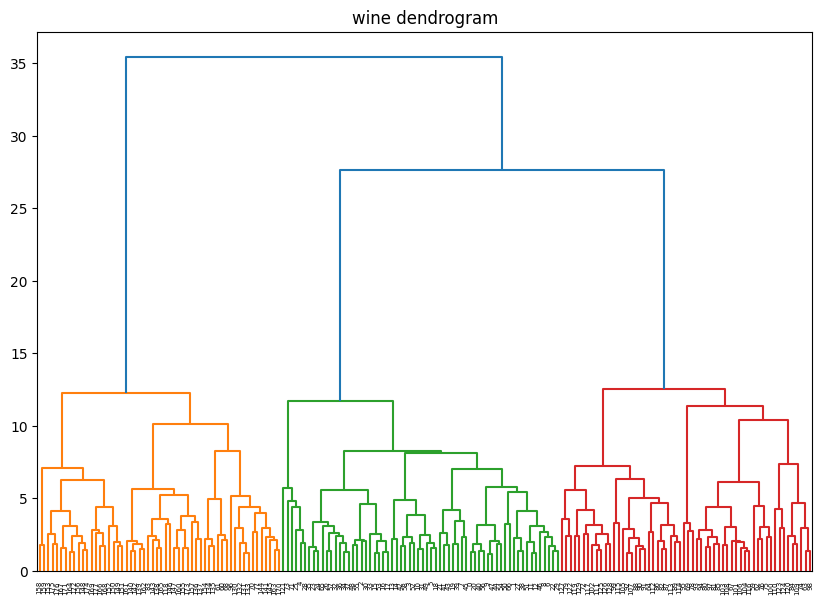

In [55]:
plt.figure(figsize=(10,7))
plt.title("wine dendrogram")
dend = shc.dendrogram(shc.linkage(df_scaled,method='ward'))

In [56]:
from sklearn.cluster import AgglomerativeClustering

In [57]:
cluster = AgglomerativeClustering(n_clusters = 3, metric ='euclidean',linkage ='ward')
labels_agg = cluster.fit_predict(df_scaled)

In [58]:
labels_agg

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 1, 0, 0, 0, 2,
       2, 0, 1, 0, 1, 2, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

## Visualising clustering using PCA

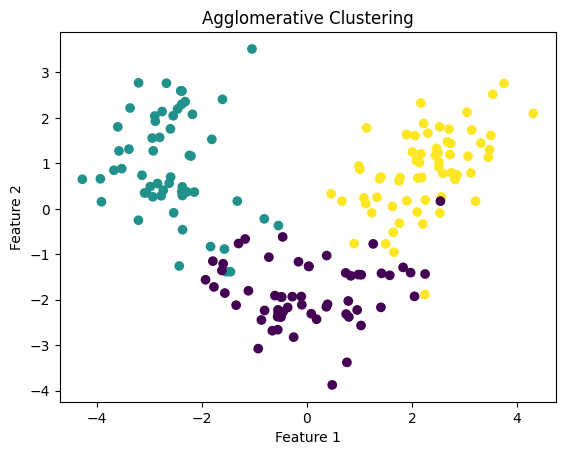

In [59]:
pca = PCA(n_components=3)
df_pca = pca.fit_transform(df_scaled)
plt.figure()
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels_agg)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Agglomerative Clustering')
plt.show()

#DBSCAN

In [60]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

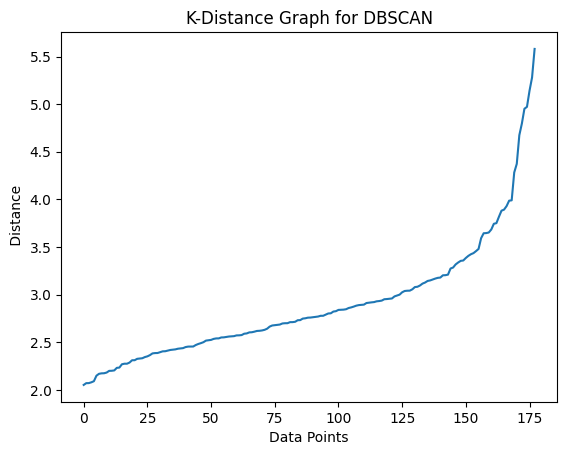

In [64]:
neighbors = NearestNeighbors(n_neighbors=14)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled) # finding the most suitable eps value from elbow graph

# Sort distances
distances = np.sort(distances[:, -1])

plt.figure()
plt.plot(distances)
plt.xlabel("Data Points")
plt.ylabel(" Distance")
plt.title("K-Distance Graph for DBSCAN")
plt.show()

In [62]:
dbscan = DBSCAN(eps=3.5, min_samples=14)
cluster1 = dbscan.fit_predict(df_scaled)

df['Cluster'] = cluster1
print(df['Cluster'].value_counts())

Cluster
 0    169
-1      9
Name: count, dtype: int64


## Visualisation using PCA

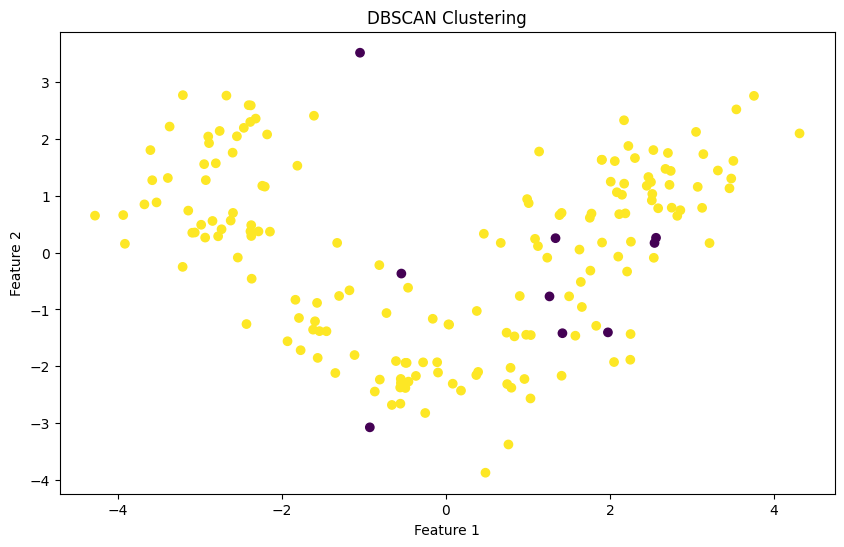

In [63]:
pca = PCA(n_components=3)
df_pca = pca.fit_transform(df_scaled)
plt.figure(figsize=(10,6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=cluster1)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('DBSCAN Clustering')
plt.show()